# Covid-19 Visualization & ML

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/corona-virus-report/covid_19_clean_complete.csv
/kaggle/input/corona-virus-report/country_wise_latest.csv
/kaggle/input/corona-virus-report/day_wise.csv
/kaggle/input/corona-virus-report/usa_county_wise.csv
/kaggle/input/corona-virus-report/worldometer_data.csv
/kaggle/input/corona-virus-report/full_grouped.csv


In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import warnings
import matplotlib.pyplot as plt

## Data Preprocessing

In [4]:
covid19Data = pd.read_csv('/kaggle/input/corona-virus-report/covid_19_clean_complete.csv')
countryData = pd.read_csv('/kaggle/input/corona-virus-report/country_wise_latest.csv')
dayData = pd.read_csv('/kaggle/input/corona-virus-report/day_wise.csv')
fullData = pd.read_csv('/kaggle/input/corona-virus-report/full_grouped.csv')
usaData = pd.read_csv('/kaggle/input/corona-virus-report/usa_county_wise.csv')
worldometerData = pd.read_csv('/kaggle/input/corona-virus-report/worldometer_data.csv')

In [5]:
warnings.filterwarnings('ignore')

In [6]:
covid19Data.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
covid19Data.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [8]:
countryData.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [9]:
countryData.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

In [10]:
dayData.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


In [11]:
dayData.columns

Index(['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases',
       'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'No. of countries'],
      dtype='object')

In [12]:
fullData.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [13]:
fullData.shape

(35156, 10)

In [14]:
fullData.columns

Index(['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region'],
      dtype='object')

In [15]:
usaData.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Date,Confirmed,Deaths
0,16,AS,ASM,16,60.0,NaN,American Samoa,US,-14.271000,-170.132000,"American Samoa, US",1/22/20,0,0
1,316,GU,GUM,316,66.0,NaN,Guam,US,13.444300,144.793700,"Guam, US",1/22/20,0,0
2,580,MP,MNP,580,69.0,NaN,Northern Mariana Islands,US,15.097900,145.673900,"Northern Mariana Islands, US",1/22/20,0,0
3,63072001,PR,PRI,630,72001.0,Adjuntas,Puerto Rico,US,18.180117,-66.754367,"Adjuntas, Puerto Rico, US",1/22/20,0,0
4,63072003,PR,PRI,630,72003.0,Aguada,Puerto Rico,US,18.360255,-67.175131,"Aguada, Puerto Rico, US",1/22/20,0,0


In [16]:
usaData.columns

Index(['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State',
       'Country_Region', 'Lat', 'Long_', 'Combined_Key', 'Date', 'Confirmed',
       'Deaths'],
      dtype='object')

In [17]:
worldometerData.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [18]:
worldometerData.columns

Index(['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases',
       'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered',
       'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop',
       'TotalTests', 'Tests/1M pop', 'WHO Region'],
      dtype='object')

In [19]:
print(fullData.head())
print(fullData.head())

         Date Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0  2020-01-22    Afghanistan          0       0          0       0          0   
1  2020-01-22        Albania          0       0          0       0          0   
2  2020-01-22        Algeria          0       0          0       0          0   
3  2020-01-22        Andorra          0       0          0       0          0   
4  2020-01-22         Angola          0       0          0       0          0   

   New deaths  New recovered             WHO Region  
0           0              0  Eastern Mediterranean  
1           0              0                 Europe  
2           0              0                 Africa  
3           0              0                 Europe  
4           0              0                 Africa  
         Date Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0  2020-01-22    Afghanistan          0       0          0       0          0   
1  2020-01-22        Albani

In [20]:
fullData.isnull().sum()

Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region        0
dtype: int64

In [21]:
worldometerData.isnull().sum()

Country/Region        0
Continent             1
Population            1
TotalCases            0
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases           4
Serious,Critical     87
Tot Cases/1M pop      1
Deaths/1M pop        22
TotalTests           18
Tests/1M pop         18
WHO Region           25
dtype: int64

In [22]:
worldometerData.fillna(0, inplace=True)

In [23]:
worldometerData.isnull().sum()

Country/Region      0
Continent           0
Population          0
TotalCases          0
NewCases            0
TotalDeaths         0
NewDeaths           0
TotalRecovered      0
NewRecovered        0
ActiveCases         0
Serious,Critical    0
Tot Cases/1M pop    0
Deaths/1M pop       0
TotalTests          0
Tests/1M pop        0
WHO Region          0
dtype: int64

In [24]:
merged_data = pd.merge(fullData, worldometerData, on='Country/Region', how='outer')

merged_data.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region_x,...,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region_y
0,2020-01-22,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean,...,0.0,25840.0,0.0,9758.0,31.0,946.0,33.0,90396.0,2317.0,EasternMediterranean
1,2020-01-23,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean,...,0.0,25840.0,0.0,9758.0,31.0,946.0,33.0,90396.0,2317.0,EasternMediterranean
2,2020-01-24,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean,...,0.0,25840.0,0.0,9758.0,31.0,946.0,33.0,90396.0,2317.0,EasternMediterranean
3,2020-01-25,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean,...,0.0,25840.0,0.0,9758.0,31.0,946.0,33.0,90396.0,2317.0,EasternMediterranean
4,2020-01-26,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean,...,0.0,25840.0,0.0,9758.0,31.0,946.0,33.0,90396.0,2317.0,EasternMediterranean


In [25]:
merged_data.shape

(35194, 25)

In [26]:
merged_data.columns

Index(['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region_x', 'Continent',
       'Population', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths',
       'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical',
       'Tot Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop',
       'WHO Region_y'],
      dtype='object')

In [27]:
merged_data.isnull().sum()

Date                  38
Country/Region         0
Confirmed             38
Deaths                38
Recovered             38
Active                38
New cases             38
New deaths            38
New recovered         38
WHO Region_x          38
Continent           3008
Population          3008
TotalCases          3008
NewCases            3008
TotalDeaths         3008
NewDeaths           3008
TotalRecovered      3008
NewRecovered        3008
ActiveCases         3008
Serious,Critical    3008
Tot Cases/1M pop    3008
Deaths/1M pop       3008
TotalTests          3008
Tests/1M pop        3008
WHO Region_y        3008
dtype: int64

In [28]:
# Dropping unnecessary columns
columns_to_drop = ['WHO Region_y', 'Serious,Critical','Population','NewCases','NewDeaths','NewRecovered','ActiveCases','Tot Cases/1M pop','Deaths/1M pop','TotalTests','Tests/1M pop']  # Dropping 'WHO Region_y' as it's redundant
merged_data = merged_data.drop(columns=columns_to_drop)

# Check the shape after dropping columns
print(merged_data.shape)

(35194, 14)


In [29]:
# Checking for duplicates
duplicates = merged_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Dropping duplicates if any
merged_data = merged_data.drop_duplicates()

# Check the shape after dropping duplicates
print(merged_data.shape)

Number of duplicate rows: 0
(35194, 14)


In [30]:
# Filling missing data
# For time-series data, forward fill might be appropriate
merged_data['Confirmed'].fillna(method='ffill', inplace=True)
merged_data['Deaths'].fillna(method='ffill', inplace=True)
merged_data['Recovered'].fillna(method='ffill', inplace=True)
merged_data['Active'].fillna(method='ffill', inplace=True)

# Filling remaining NaNs with 0 where forward fill doesn't make sense
merged_data.fillna(0, inplace=True)

# Check if there are still missing values
print(merged_data.isnull().sum())

Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region_x      0
Continent         0
TotalCases        0
TotalDeaths       0
TotalRecovered    0
dtype: int64


In [31]:
# Final structure of the cleaned dataset
print(merged_data.shape)
print(merged_data.columns)
print(merged_data.isnull().sum())

(35194, 14)
Index(['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region_x', 'Continent',
       'TotalCases', 'TotalDeaths', 'TotalRecovered'],
      dtype='object')
Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region_x      0
Continent         0
TotalCases        0
TotalDeaths       0
TotalRecovered    0
dtype: int64


In [32]:
print(merged_data['Country/Region'].unique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei' 'Brunei '
 'Bulgaria' 'Burkina Faso' 'Burma' 'Burundi' 'CAR' 'Cabo Verde' 'Cambodia'
 'Cameroon' 'Canada' 'Caribbean Netherlands' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Channel Islands' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo' 'Congo (Brazzaville)' 'Congo (Kinshasa)'
 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curaçao' 'Cyprus'
 'Czechia' 'DRC' 'Denmark' 'Diamond Princess' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Faeroe Islands'
 'Falkland Islands' 'Fiji' 'Finland' 'France' 'French Guiana'
 'French Polynesia' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Gibralt

In [33]:
country = 'US'  # or any country you want to analyze

In [34]:
# Check if there are any rows for the specified country
print(merged_data[merged_data['Country/Region'] == country].shape)
print(merged_data[merged_data['Country/Region'] == country].head())

# Check for missing values in relevant columns
print(merged_data[['Date', 'Confirmed', 'New cases', 'New deaths']].isnull().sum())

(188, 14)
             Date Country/Region  Confirmed  Deaths  Recovered  Active  \
32560  2020-01-22             US        1.0     0.0        0.0     1.0   
32561  2020-01-23             US        1.0     0.0        0.0     1.0   
32562  2020-01-24             US        2.0     0.0        0.0     2.0   
32563  2020-01-25             US        2.0     0.0        0.0     2.0   
32564  2020-01-26             US        5.0     0.0        0.0     5.0   

       New cases  New deaths  New recovered WHO Region_x Continent  \
32560        0.0         0.0            0.0     Americas         0   
32561        0.0         0.0            0.0     Americas         0   
32562        1.0         0.0            0.0     Americas         0   
32563        0.0         0.0            0.0     Americas         0   
32564        3.0         0.0            0.0     Americas         0   

       TotalCases  TotalDeaths  TotalRecovered  
32560         0.0          0.0             0.0  
32561         0.0         

In [35]:
# Convert 'Date' column to datetime
merged_data['Date'] = pd.to_datetime(merged_data['Date'], errors='coerce')

# Check the result
print(merged_data['Date'].dtype)
print(merged_data['Date'].isnull().sum())

datetime64[ns]
38


In [36]:
# Drop rows where 'Date' is NaT
merged_data = merged_data.dropna(subset=['Date'])

# Now check the minimum and maximum dates again
country_data = merged_data[merged_data['Country/Region'] == 'US']  # or 'USA'
print(country_data['Date'].min(), country_data['Date'].max())

2020-01-22 00:00:00 2020-07-27 00:00:00


In [37]:
# Check data types
print(merged_data.dtypes)

# Check for any unexpected values
print(merged_data[['Confirmed', 'New cases', 'New deaths']].describe())

Date              datetime64[ns]
Country/Region            object
Confirmed                float64
Deaths                   float64
Recovered                float64
Active                   float64
New cases                float64
New deaths               float64
New recovered            float64
WHO Region_x              object
Continent                 object
TotalCases               float64
TotalDeaths              float64
TotalRecovered           float64
dtype: object
          Confirmed    New cases    New deaths
count  3.515600e+04  35156.00000  35156.000000
mean   2.356663e+04    469.36375     18.603339
std    1.499818e+05   3005.86754    115.706351
min    0.000000e+00      0.00000  -1918.000000
25%    1.000000e+00      0.00000      0.000000
50%    2.500000e+02      2.00000      0.000000
75%    3.640250e+03     75.00000      1.000000
max    4.290259e+06  77255.00000   3887.000000


## Exploratory Data Analysis (EDA)

In [38]:
merged_data.describe()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,TotalCases,TotalDeaths,TotalRecovered
count,35156,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000,3.515600e+04,35156.000000,3.515600e+04
mean,2020-04-24 12:00:00,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593,7.317975e+04,2686.117647,5.014255e+04
min,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000,0.000000e+00,0.000000,0.000000e+00
25%,2020-03-08 18:00:00,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,8.040000e+02,11.000000,3.040000e+02
50%,2020-04-24 12:00:00,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000,4.680000e+03,83.000000,2.178000e+03
75%,2020-06-10 06:00:00,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000,3.981900e+04,763.000000,2.584000e+04
max,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000,2.917562e+06,98644.000000,2.047660e+06
std,NaN,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852,2.761264e+05,9687.159627,1.940320e+05


In [39]:
fig = px.choropleth(
    merged_data.groupby('Country/Region').max().reset_index(),
    locations="Country/Region",
    locationmode="country names",
    color="Confirmed",
    hover_name="Country/Region",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Total Confirmed COVID-19 Cases by Country"
)
fig.show()


In [40]:
# Group by date to get global daily new cases
global_daily_data = merged_data.groupby('Date')['New cases'].sum().reset_index()

# Plot
fig = px.line(
    global_daily_data,
    x='Date',
    y='New cases',
    title='Daily New COVID-19 Cases Worldwide',
    labels={'Date': 'Date', 'New cases': 'New Cases'}
)
fig.show()


In [41]:
fig = px.scatter(
    merged_data,
    x='Confirmed',
    y='Deaths',
    color='Country/Region',
    title='Confirmed Cases vs Deaths by Country',
    labels={'Confirmed': 'Confirmed Cases', 'Deaths': 'Deaths'},
    log_x=True,
    log_y=True
)
fig.show()


In [42]:
fig = px.box(
    merged_data,
    x='Continent',
    y='New cases',
    title='Distribution of Daily New Cases by Continent',
    labels={'New cases': 'New Cases', 'Continent': 'Continent'}
)
fig.show()

In [43]:
fig = px.imshow(
    merged_data.pivot_table(index='Date', columns='Country/Region', values='Confirmed'),
    title='Heatmap of Confirmed Cases by Country and Date',
    labels={'x': 'Country/Region', 'y': 'Date', 'color': 'Confirmed Cases'}
)
fig.show()


In [44]:
fig = px.choropleth(
    merged_data.groupby('Country/Region').agg({'Confirmed': 'max'}).reset_index(),
    locations='Country/Region',
    locationmode='country names',
    color='Confirmed',
    title='COVID-19 Total Cases by Country',
    color_continuous_scale='Viridis',
    labels={'Confirmed': 'Total Cases'}
)
fig.show()

# Models

## Time Series Forecasting

In [45]:
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [46]:
# Filter data for a specific country
country_data = merged_data[merged_data['Country/Region'] == 'US']
country_data = country_data.set_index('Date')['Confirmed'].resample('D').sum()

In [47]:
country_data

Date
2020-01-22          1.0
2020-01-23          1.0
2020-01-24          2.0
2020-01-25          2.0
2020-01-26          5.0
                ...    
2020-07-23    4038816.0
2020-07-24    4112531.0
2020-07-25    4178970.0
2020-07-26    4233923.0
2020-07-27    4290259.0
Freq: D, Name: Confirmed, Length: 188, dtype: float64

In [48]:
# Ensure your data is a Pandas Series or DataFrame with a DateTime index
country_data.index = pd.to_datetime(country_data.index)

country_data.dropna(inplace=True)

In [49]:
result = adfuller(country_data)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])


ADF Statistic: 2.5751773337311703
p-value: 0.9990701498156939
Critical Values: {'1%': -3.467845319799907, '5%': -2.878011745497439, '10%': -2.575551186759871}


In [50]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(country_data.values.reshape(-1, 1))
scaled_series = pd.Series(scaled_data.flatten(), index=country_data.index)

model = ARIMA(scaled_series, order=(5, 1, 0))
model_fit = model.fit()


In [51]:
forecast = model_fit.forecast(steps=30)  # Forecast for next 30 days

Mean Absolute Error: 398652.88390665763
Mean Squared Error: 347989223969.59265
Root Mean Squared Error: 589906.1145382312


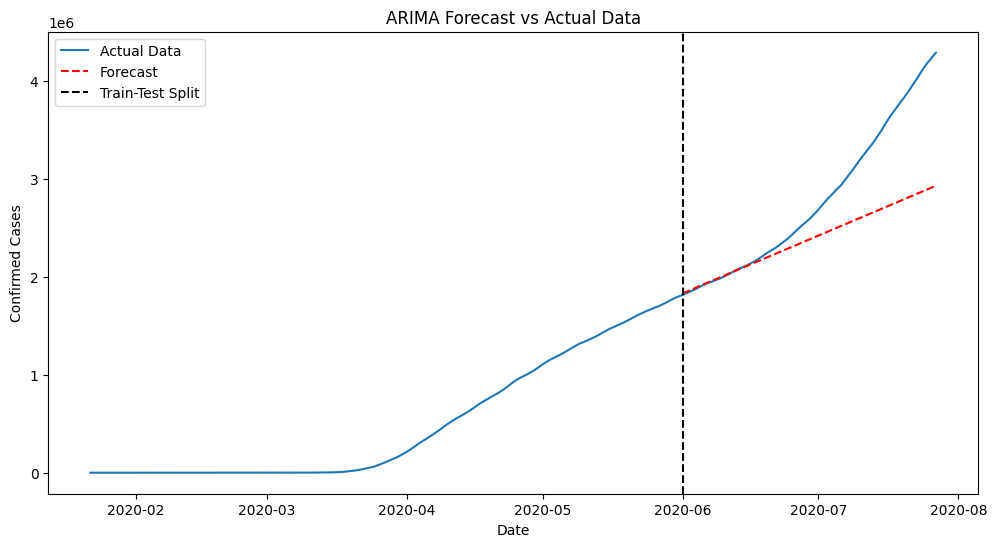

In [52]:
# Define the split point
split_date = '2020-06-01'  # Adjust this date based on your data
train_data = country_data[:split_date]
test_data = country_data[split_date:]

# Fit ARIMA model on training data
model = ARIMA(train_data, order=(5, 1, 0))
model_fit = model.fit()

# Forecast on test data
forecast = model_fit.forecast(steps=len(test_data))

# Calculate accuracy metrics
mae = mean_absolute_error(test_data, forecast)
mse = mean_squared_error(test_data, forecast)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

# Plot the results for visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(country_data.index, country_data, label='Actual Data')
plt.plot(test_data.index, forecast, color='red', linestyle='--', label='Forecast')
plt.axvline(x=pd.to_datetime(split_date), color='black', linestyle='--', label='Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.title('ARIMA Forecast vs Actual Data')
plt.legend()
plt.show()


## Regression model

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [54]:
# Filter data for a specific country
country_data = merged_data[merged_data['Country/Region'] == 'US']  # or 'USA'

# Drop rows with missing target or feature values
country_data = country_data.dropna(subset=['Confirmed', 'New cases', 'New deaths'])

# Select features and target variable
features = ['New cases', 'New deaths']  # You can add more features if available
target = 'Confirmed'

# Prepare feature matrix (X) and target vector (y)
X = country_data[features]
y = country_data[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [55]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [56]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


Mean Squared Error: 263989136784.59
R-squared: 0.84


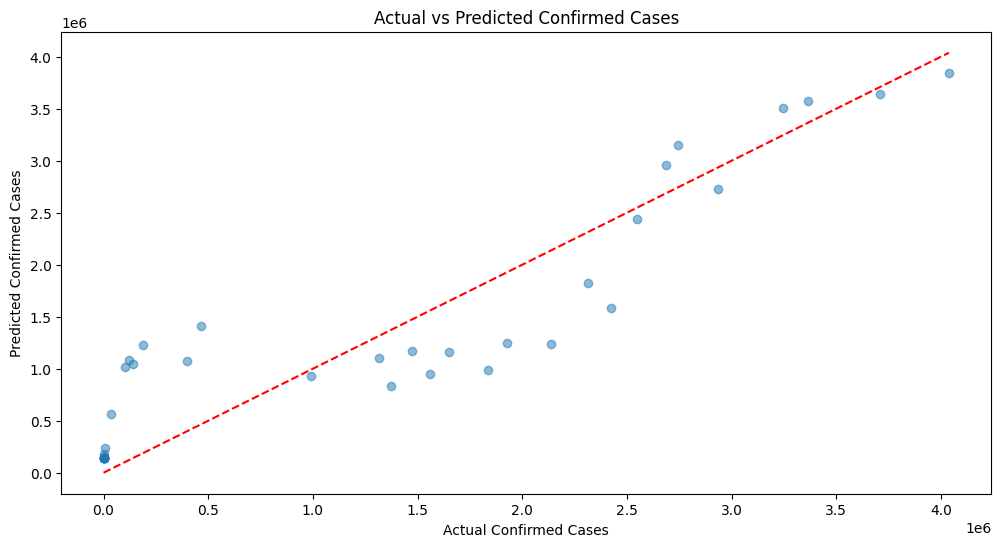

In [57]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Confirmed Cases')
plt.ylabel('Predicted Confirmed Cases')
plt.title('Actual vs Predicted Confirmed Cases')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Diagonal line
plt.show()


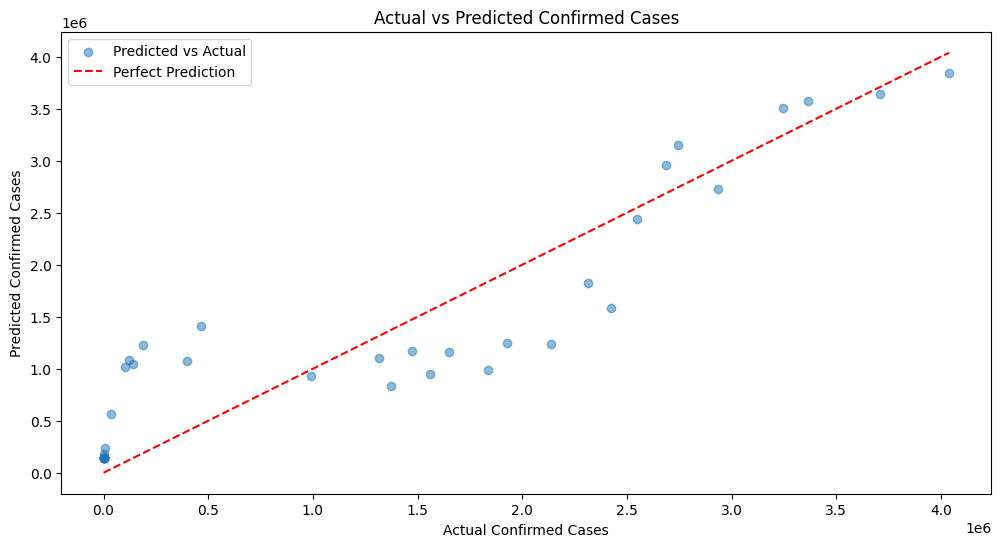

In [58]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predicted vs Actual')
plt.xlabel('Actual Confirmed Cases')
plt.ylabel('Predicted Confirmed Cases')
plt.title('Actual vs Predicted Confirmed Cases')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')  # Diagonal line
plt.legend()  # Add legend
plt.show()


## Classification model

In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [60]:
# Define the risk levels based on the number of confirmed cases
def classify_risk(x):
    if x < 10000:
        return 'Low'
    elif x < 100000:
        return 'Medium'
    else:
        return 'High'

# Apply the classification function
merged_data['Risk'] = merged_data['Confirmed'].apply(classify_risk)

# Filter out rows with missing values in the target variable
data = merged_data.dropna(subset=['Risk', 'New cases', 'New deaths'])

# Select features and target variable
features = ['New cases', 'New deaths']
target = 'Risk'

# Prepare feature matrix (X) and target vector (y)
X = data[features]
y = data[target]

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [62]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.89
Classification Report:
              precision    recall  f1-score   support

        High       0.62      0.59      0.60       319
         Low       0.94      0.96      0.95      5863
      Medium       0.59      0.52      0.55       850

    accuracy                           0.89      7032
   macro avg       0.72      0.69      0.70      7032
weighted avg       0.89      0.89      0.89      7032



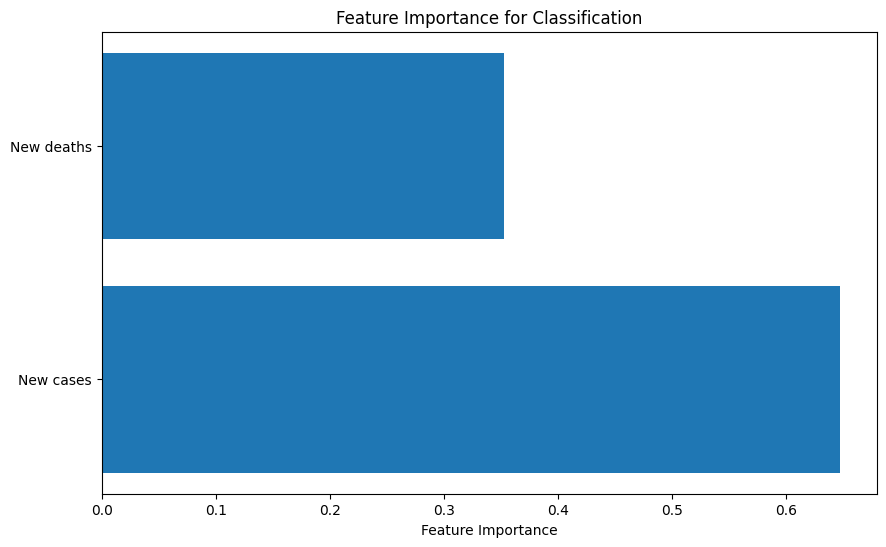

In [63]:
# Plot feature importances
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Classification')
plt.show()

## Clustering model

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [65]:
# Select features for clustering
features = ['Confirmed', 'New cases', 'New deaths', 'Deaths', 'Recovered']

# Filter out rows with missing values
data = merged_data.dropna(subset=features)

# Prepare feature matrix (X)
X = data[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

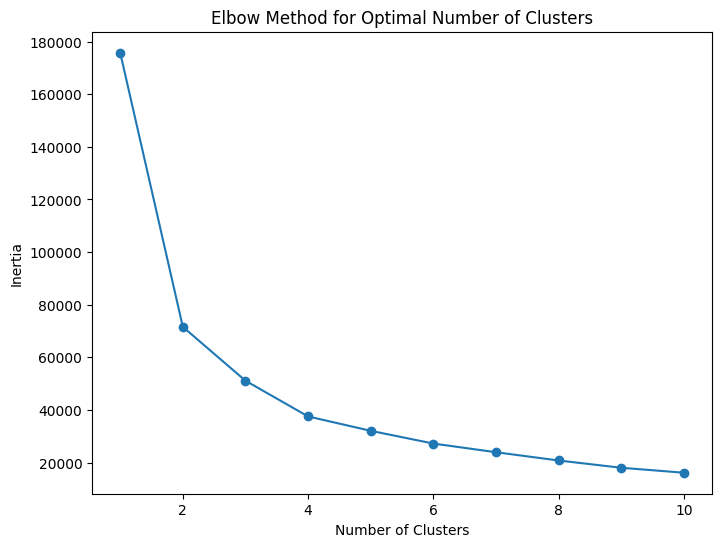

In [66]:
# Determine the optimal number of clusters
inertia = []
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

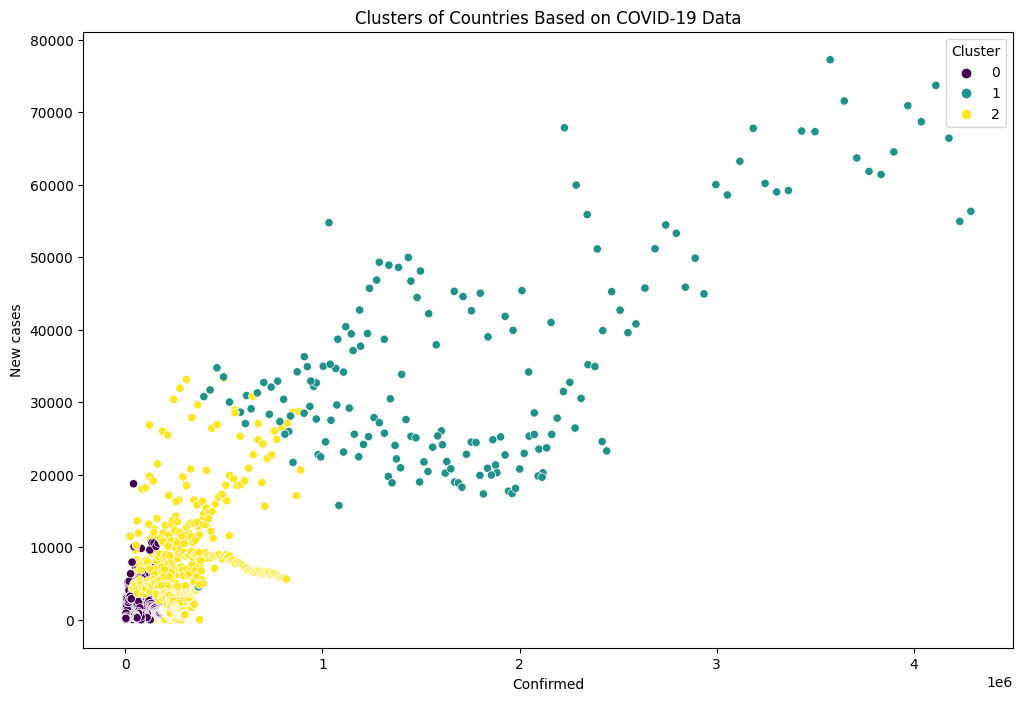

In [67]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Confirmed', y='New cases', hue='Cluster', data=data, palette='viridis')
plt.title('Clusters of Countries Based on COVID-19 Data')
plt.show()
